In [ ]:
import numpy as np
from PIL import Image, UnidentifiedImageError
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import pairwise_distances_argmin_min
from tensorflow.keras.callbacks import ReduceLROnPlateau
import os, json, time

IMG_SIZE = (150, 150)

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 3e-5

DINO_FOLDER = "dataset/dinosaur"
NON_DINO_FOLDER = "dataset/not_dinosaur"

MODEL_PATH = "models/stage1_binary.keras"

Завантажуємо наші картинки з динозаврами

In [4]:
dino_paths = glob("dataset/dinosaur/**/*.*", recursive=True)
dino_images = []

for path in tqdm(dino_paths, desc="Завантаження динозаврів"):
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        dino_images.append(np.array(img))
    except (UnidentifiedImageError, OSError):
            print(f"Пропускаємо файл: {path}")

dino_images = np.array(dino_images)
dino_labels = np.ones(len(dino_images), dtype=np.int32)
print("Готово! Завантажено динозаврів:", dino_images.shape)

from PIL import Image, UnidentifiedImageError


Завантаження динозаврів:   0%|          | 0/6690 [00:00<?, ?it/s]

Завантаження динозаврів: 100%|██████████| 6690/6690 [04:01<00:00, 27.73it/s]


Готово! Завантажено динозаврів: (6690, 150, 150, 3)


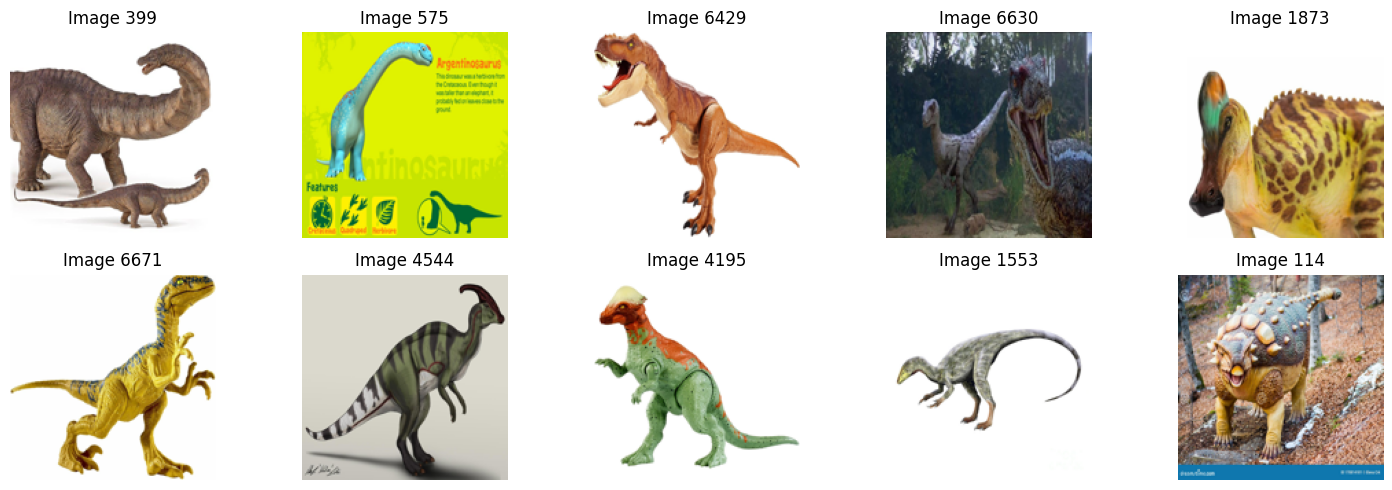

In [5]:
import random
import matplotlib.pyplot as plt

num_show = 10

indices = random.sample(range(len(dino_images)), num_show)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(dino_images[idx])
    plt.axis('off')
    plt.title(f"Image {idx}")

plt.tight_layout()
plt.show()

Завантаження 'Не динозаврів'

In [6]:
from PIL import Image, UnidentifiedImageError

not_dino_paths = glob("dataset/not_dinosaur/**/*.*", recursive=True)
not_dino_images = []

for path in tqdm(not_dino_paths, desc="Завантаження не-динозаврів"):
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        not_dino_images.append(np.array(img))
    except (UnidentifiedImageError, OSError):
        print(f"Пропускаємо файл: {path}")

not_dino_images = np.array(not_dino_images)
not_dino_labels = np.zeros(len(not_dino_images), dtype=np.int32)

print("Готово! Завантажено не-динозаврів:", not_dino_images.shape)


Завантаження не-динозаврів:  32%|███▏      | 2542/8026 [01:15<01:35, 57.40it/s]

Пропускаємо файл: dataset/not_dinosaur\Dog\Thumbs.db


Завантаження не-динозаврів: 100%|██████████| 8026/8026 [02:43<00:00, 49.09it/s] 


Готово! Завантажено не-динозаврів: (8025, 150, 150, 3)


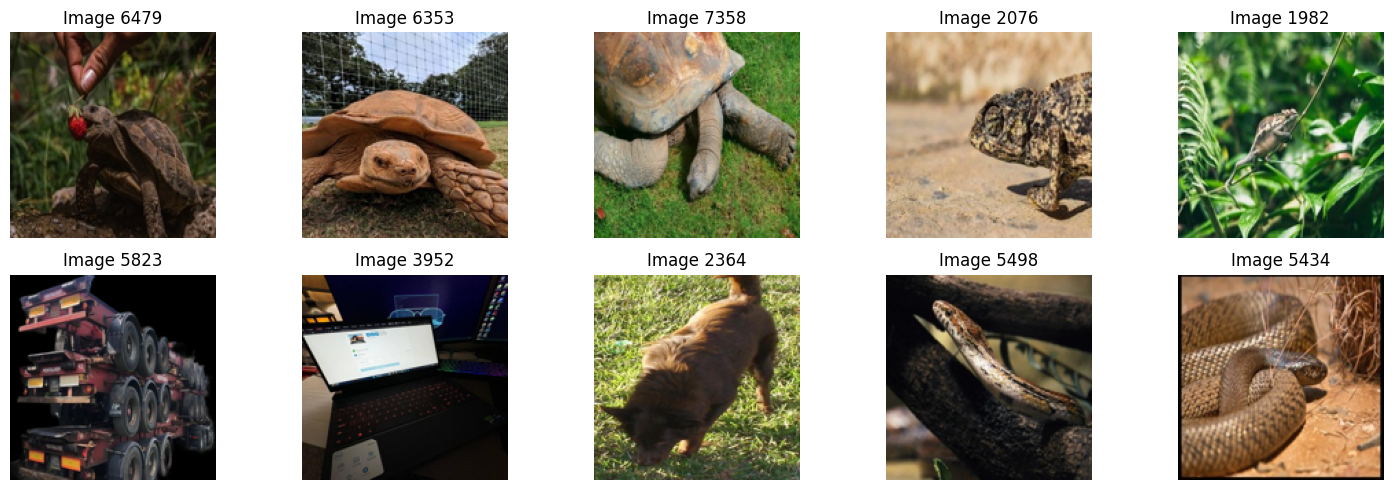

In [7]:
import random
import matplotlib.pyplot as plt

num_show = 10

indices = random.sample(range(len(not_dino_images)), num_show)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(not_dino_images[idx])
    plt.axis('off')
    plt.title(f"Image {idx}")

plt.tight_layout()
plt.show()

Створення фінального дадасету

In [8]:
X = np.concatenate([dino_images, not_dino_images], axis=0).astype("float32") / 255.0
y = np.concatenate([dino_labels, not_dino_labels], axis=0)

print("Фінальний датасет:", X.shape, y.shape)

Фінальний датасет: (14715, 150, 150, 3) (14715,)


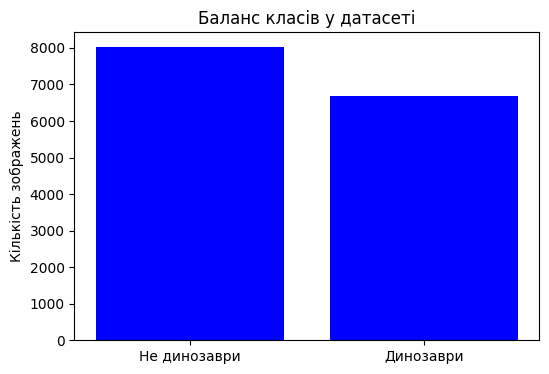

Клас 0: 8025 зображень
Клас 1: 6690 зображень


In [9]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(['Не динозаври', 'Динозаври'], counts, color=['blue', 'blue'])
plt.title("Баланс класів у датасеті")
plt.ylabel("Кількість зображень")
plt.show()

for u, c in zip(unique, counts):
    print(f"Клас {u}: {c} зображень")

Підготовка даних до навчання

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

Створення генераторів

In [35]:
train_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_gen = ImageDataGenerator()

train_flow = train_gen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_flow = val_gen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False 
)

Class weights

In [36]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, class_weights_array))

Створення CNN моделі

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

model = create_model()
model.summary()


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,513 (40.86 MB)

 Trainable params: 10,711,553 (40.86 MB)

 Non-trainable params: 960 (3.75 KB)

Callbacks

In [38]:
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

Запуск

In [ ]:
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
322/322 - 387s - 1s/step - accuracy: 0.7381 - auc: 0.8300 - loss: 0.5179 - precision: 0.6912 - recall: 0.7662 - val_accuracy: 0.7241 - val_auc: 0.7832 - val_loss: 0.5598 - val_precision: 0.7127 - val_recall: 0.6580 - learning_rate: 3.0000e-05
Epoch 2/50
322/322 - 391s - 1s/step - accuracy: 0.7864 - auc: 0.8732 - loss: 0.4459 - precision: 0.7539 - recall: 0.7871 - val_accuracy: 0.7367 - val_auc: 0.8925 - val_loss: 0.5202 - val_precision: 0.6482 - val_recall: 0.9202 - learning_rate: 3.0000e-05
Epoch 3/50
322/322 - 378s - 1s/step - accuracy: 0.8022 - auc: 0.8885 - loss: 0.4168 - precision: 0.7782 - recall: 0.7903 - val_accuracy: 0.8183 - val_auc: 0.8935 - val_loss: 0.4063 - val_precision: 0.8244 - val_recall: 0.7627 - learning_rate: 3.0000e-05
Epoch 4/50
322/322 - 373s - 1s/step - accuracy: 0.8258 - auc: 0.9048 - loss: 0.3888 - precision: 0.8098 - recall: 0.8063 - val_accuracy: 0.8283 - val_auc: 0.9097 - val_loss: 0.3809 - val_precision: 0.8177 - val_recall: 0.8006 - learning_r

In [45]:
model.save(MODEL_PATH)
print(f"Модель збережена за шляхом: {MODEL_PATH}")

Модель збережена за шляхом: models/stage1_binary.keras


Візуалізація

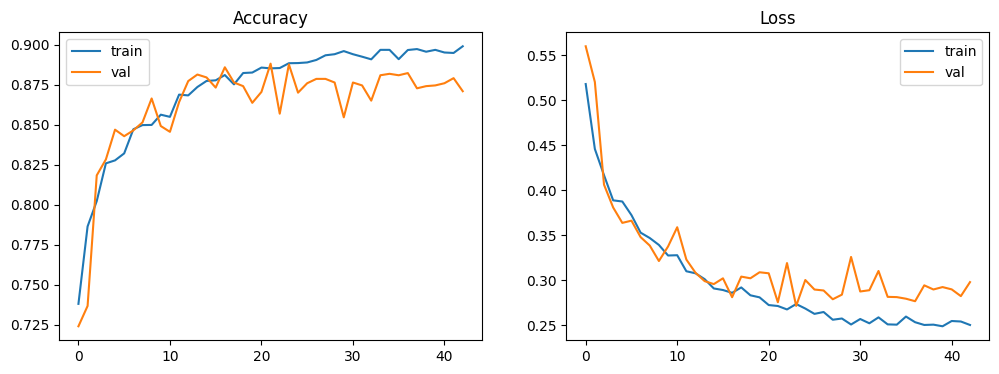

In [41]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step


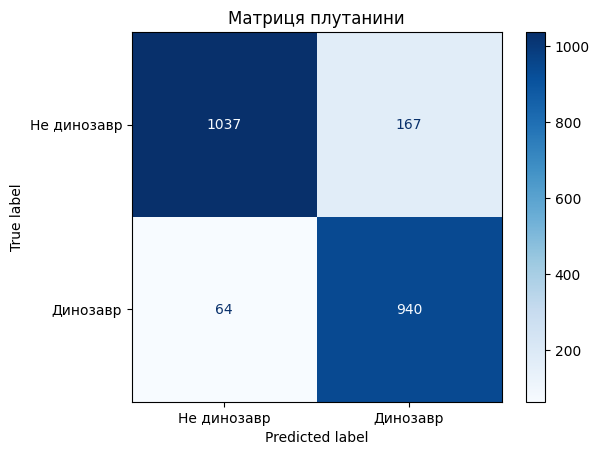

In [42]:
y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Не динозавр", "Динозавр"])
disp.plot(cmap="Blues")

plt.title("Матриця плутанини")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


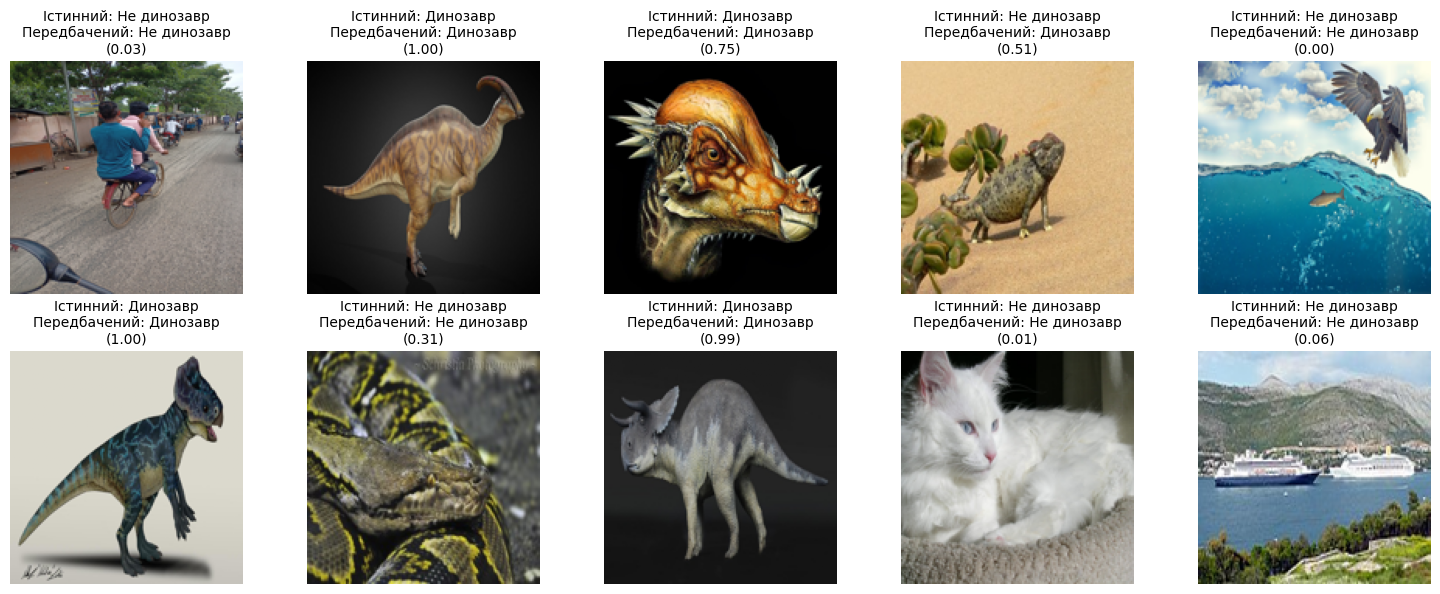

In [43]:
import random
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

class_names = ["Не динозавр", "Динозавр"]

indices = random.sample(range(len(X_test)), 10)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    img = X_test[idx] 
    true_label = int(y_test[idx])

    pred_prob = model.predict(img.reshape(1, IMG_SIZE[0], IMG_SIZE[1], 3))[0][0]
    pred_label = int(pred_prob >= 0.5)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Істинний: {class_names[true_label]}\nПередбачений: {class_names[pred_label]}\n({pred_prob:.2f})", fontsize=10)

plt.tight_layout()
plt.show()
